In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten, Dense,Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [ ]:
train_dir = "/content/drive/MyDrive/DATA Palmistry"
img_width,img_height= 200,200
batch_size = 128
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=40,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   fill_mode='nearest')
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width,img_height),
    batch_size=batch_size,
    class_mode='categorical')

Found 259 images belonging to 4 classes.


In [ ]:
model = Sequential([
    Conv2D(32,(3,3),activation = 'relu',input_shape = (200,200,3)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation = 'relu'),
    MaxPooling2D((2,2)),
    Conv2D(128,(3,3),activation = 'relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation = 'relu'),
    Dropout(0.5),
    Dense(4,activation = 'softmax')
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     8,667,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,761,028 (33.42 MB)

 Trainable params: 8,761,028 (33.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer = 'adam',loss = 'categorical_crossentropy',metrics = ['accuracy'])
history = model.fit(train_generator,epochs = 10)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 40s 19s/step - accuracy: 0.2857 - loss: 6.7742
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 29s 7s/step - accuracy: 0.2973 - loss: 1.6274
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 25s 12s/step - accuracy: 0.3552 - loss: 1.3293
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 12s/step - accuracy: 0.2703 - loss: 1.3790
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 27s 13s/step - accuracy: 0.4903 - loss: 1.2209
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 27s 13s/step - accuracy: 0.6062 - loss: 1.0937
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 24s 5s/step - accuracy: 0.6950 - loss: 0.9645
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 27s 7s/step - accuracy: 0.7066 - loss: 0.7558
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 27s 6s/step - accuracy: 0.7799 - loss: 0.6183
Epoch 10/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 25s 6s/step - accuracy: 0.7954 - loss: 0.5175


In [ ]:
model.save("model_palmistry.h5")

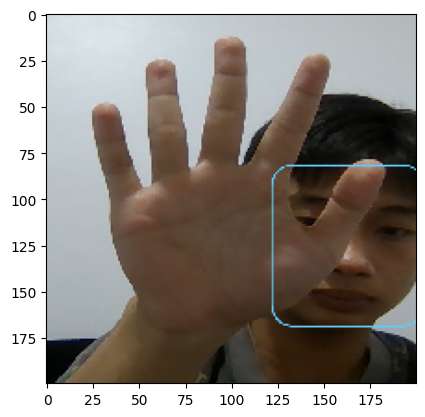

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
Dự đoán : Cuộc sống ổn định ( ít đường đứt đoạn )


In [ ]:
from keras.utils import load_img
import numpy as np
import matplotlib.pyplot as plt

path ="/content/Screenshot 2026-05-30 184619.png"
img = load_img(path, target_size=(200, 200))
plt.imshow(img)
plt.show()
img = np.array(img)
img = img / 255.0
img = img.reshape(1, 200, 200, 3)
prediction=np.argmax(model.predict(img))
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Dự đoán : {person_name}")